# Ensemble Averaging — Credit Risk Default Prediction

**4 diverse base models → simple probability averaging.**

### Base models (4 diverse learners)
- **XGBoost** — gradient boosting
- **Random Forest** — bagging
- **MLP-A** — [64, 32, 16] + BatchNorm + Dropout
- **MLP-B** — [128, 64] + Dropout (different inductive bias)

### Ensemble
Simple probability average: `(xgb + rf + mlp_a + mlp_b) / 4`. Beats LogReg meta-model on recall (0.62 vs 0.35) and F1 (0.55 vs 0.46).

### Evaluation
Compare: individual base models vs ensemble average

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, brier_score_loss,
    precision_recall_curve, average_precision_score, RocCurveDisplay
)
from xgboost import XGBClassifier

import mlflow

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}  |  XGBoost: {XGBClassifier.__module__}")

/home/momo/Documents/internship/week-03/credit-risk-pipeline/.venv/lib/python3.12/site-packages/mlflow/utils/autologging_utils/versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Device: cpu
PyTorch: 2.12.0+cu130  |  XGBoost: xgboost.sklearn


/home/momo/Documents/internship/week-03/credit-risk-pipeline/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# Local environment — reads from ../../data/processed/
DATA_PATH = "/home/momo/Documents/internship/week-03/credit-risk-pipeline/data/processed"
OUT_DIR = "/home/momo/Documents/internship/week-03/credit-risk-pipeline/data-mining/building-nns/output/stacking-ensemble"
import os
os.makedirs(OUT_DIR, exist_ok=True)
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUT_DIR:   {OUT_DIR}")


DATA_PATH: /home/momo/Documents/internship/week-03/credit-risk-pipeline/data/processed
OUT_DIR:   /home/momo/Documents/internship/week-03/credit-risk-pipeline/data-mining/building-nns/output/stacking-ensemble


In [3]:
# =============================================================================
# MLflow — experiment tracking (Docker server)
# =============================================================================
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("credit-risk-default")


run = mlflow.start_run(run_name="ensemble-avg-4-models")
print(f"MLflow run: {run.info.run_id[:8]}...  |  tracking: http://localhost:5000")

MLflow run: fe5eb9ea...  |  tracking: http://localhost:5000


In [4]:
# --- Load data ---
# Reads from DATA_PATH (set in the environment setup cell above)
train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
val_df   = pd.read_csv(f"{DATA_PATH}/val.csv")
test_df  = pd.read_csv(f"{DATA_PATH}/test.csv")

# Combine train + val for K-Fold CV (val is used for early stopping in NN base models)
full_train_df = pd.concat([train_df, val_df], ignore_index=True)

X_full = full_train_df.drop(columns=['DEFAULT_OCT']).values.astype(np.float32)
y_full = full_train_df['DEFAULT_OCT'].values.astype(np.float32)

X_test = test_df.drop(columns=['DEFAULT_OCT']).values.astype(np.float32)
y_test = test_df['DEFAULT_OCT'].values.astype(np.float32)

print(f"Full train (for CV): {X_full.shape[0]:,} samples, {X_full.shape[1]} features")
print(f"Test:               {X_test.shape[0]:,} samples")
print(f"Default rate: {y_full.mean():.4f}")

Full train (for CV): 25,500 samples, 10 features
Test:               4,500 samples
Default rate: 0.2212


In [5]:
# =============================================================================
# PyTorch MLP definitions
# =============================================================================

class MLPBase(nn.Module):
    """Generic MLP with configurable hidden dims and dropout."""
    def __init__(self, input_dim, hidden_dims, dropout_rates, use_batchnorm=True):
        super().__init__()
        layers = []
        prev = input_dim
        for hd, dr in zip(hidden_dims, dropout_rates):
            layers.append(nn.Linear(prev, hd))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hd))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dr))
            prev = hd
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, 1)

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(-1)


def make_mlp_a(input_dim):
    """MLP-A: [64, 32, 16] + BatchNorm + Dropout"""
    return MLPBase(input_dim, [64, 32, 16], [0.3, 0.3, 0.2], use_batchnorm=True)


def make_mlp_b(input_dim):
    """MLP-B: [128, 64] + Dropout only (no BatchNorm) — different inductive bias"""
    return MLPBase(input_dim, [128, 64], [0.4, 0.3], use_batchnorm=False)

input_dim = X_full.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 10


In [6]:
# =============================================================================
# PyTorch training helper
# =============================================================================

def train_mlp(model, X_train, y_train, X_val, y_val,
              epochs=80, batch_size=256, lr=1e-3, patience=15, verbose=False):
    """Train an MLP with early stopping. Returns trained model."""
    model = model.to(device)

    pos_count = y_train.sum()
    neg_count = len(y_train) - pos_count
    pos_weight = neg_count / max(pos_count, 1)

    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size * 2, shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_state)
    return model


def predict_mlp(model, X):
    """Return probability predictions for an MLP."""
    model.eval()
    model = model.to(device)
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32))
    loader = DataLoader(ds, batch_size=1024, shuffle=False)
    probs = []
    with torch.no_grad():
        for (Xb,) in loader:
            Xb = Xb.to(device)
            probs.extend(torch.sigmoid(model(Xb)).cpu().numpy())
    return np.array(probs)

In [7]:
# =============================================================================
# Optuna Tuning — XGBoost, RandomForest, Meta-model C
# =============================================================================
RUN_TUNING = True
N_TRIALS   = 25

if RUN_TUNING:
    import optuna
    from optuna.samplers import TPESampler

    # Single train/val split for fast tuning (not the full K-fold)
    X_tune, X_vtune, y_tune, y_vtune = train_test_split(
        X_full, y_full, test_size=0.20, stratify=y_full, random_state=42
    )

    def objective(trial):
        # --- 1. XGBoost ---
        xgb = XGBClassifier(
            n_estimators=trial.suggest_int('xgb_n_estimators', 100, 400),
            max_depth=trial.suggest_int('xgb_max_depth', 3, 10),
            learning_rate=trial.suggest_float('xgb_lr', 0.01, 0.2, log=True),
            subsample=trial.suggest_float('xgb_subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample', 0.6, 1.0),
            scale_pos_weight=(len(y_tune)-y_tune.sum())/y_tune.sum(),
            random_state=42, eval_metric='logloss', verbosity=0
        )
        xgb.fit(X_tune, y_tune)
        xgb_auc = roc_auc_score(y_vtune, xgb.predict_proba(X_vtune)[:, 1])

        # --- 2. Random Forest ---
        rf = RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 100, 400),
            max_depth=trial.suggest_int('rf_max_depth', 6, 20),
            min_samples_leaf=trial.suggest_int('rf_min_leaf', 5, 50),
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        rf.fit(X_tune, y_tune)
        rf_auc = roc_auc_score(y_vtune, rf.predict_proba(X_vtune)[:, 1])

        # Combined score (average — both matter)
        return (xgb_auc + rf_auc) / 2

    print(f"Tuning XGBoost + RandomForest ({N_TRIALS} trials)...\n")
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f"\nBest trial #{study.best_trial.number}")
    print(f"Best avg AUC: {study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k:25s} = {v}")

    BEST_TREE_PARAMS = study.best_params

    # --- Quick meta-model C tuning (on 3-fold CV to avoid re-running full pipeline) ---
    # Use default base models for a rough meta-C search
    print("\nTuning meta-model C...")
    C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
    best_c, best_c_auc = 1.0, 0.0
    for c in C_values:
        # Simple 3-fold to evaluate meta-C
        skf_small = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof_c = np.zeros(X_full.shape[0])
        for tr_idx, oof_idx in skf_small.split(X_full, y_full):
            X_tr_c, y_tr_c = X_full[tr_idx], y_full[tr_idx]
            X_oof_c = X_full[oof_idx]

            # Quick base models
            xgb_c = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                                  scale_pos_weight=(len(y_tr_c)-y_tr_c.sum())/y_tr_c.sum(),
                                  random_state=42, eval_metric='logloss', verbosity=0)
            xgb_c.fit(X_tr_c, y_tr_c)
            rf_c = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=20,
                                          class_weight='balanced', random_state=42, n_jobs=-1)
            rf_c.fit(X_tr_c, y_tr_c)
            oof_c[oof_idx] = (xgb_c.predict_proba(X_oof_c)[:,1] + rf_c.predict_proba(X_oof_c)[:,1]) / 2

        #  This is just averaging, not full stacking — sufficient for choosing C
        auc_c = roc_auc_score(y_full, oof_c)
        if auc_c > best_c_auc:
            best_c_auc, best_c = auc_c, c

    print(f"  Best meta C: {best_c} (avg-AUC proxy: {best_c_auc:.4f})")
    BEST_META_C = best_c

else:
    print("Tuning skipped. Using defaults.")
    BEST_TREE_PARAMS = {}
    BEST_META_C = 1.0

/home/momo/Documents/internship/week-03/credit-risk-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-11 12:48:49,586] A new study created in memory with name: no-name-641edbce-ae1b-455b-bde6-d1d5c5c36323


Tuning XGBoost + RandomForest (25 trials)...



Best trial: 0. Best value: 0.767858:   4%|▍         | 1/25 [00:00<00:23,  1.04it/s]

[I 2026-06-11 12:48:50,550] Trial 0 finished with value: 0.7678580515737825 and parameters: {'xgb_n_estimators': 212, 'xgb_max_depth': 10, 'xgb_lr': 0.08960785365368121, 'xgb_subsample': 0.8394633936788146, 'xgb_colsample': 0.6624074561769746, 'rf_n_estimators': 146, 'rf_max_depth': 6, 'rf_min_leaf': 44}. Best is trial 0 with value: 0.7678580515737825.


Best trial: 1. Best value: 0.783534:   8%|▊         | 2/25 [00:01<00:21,  1.06it/s]

...

[I 2026-06-11 12:49:15,815] Trial 22 finished with value: 0.7868986942283931 and parameters: {'xgb_n_estimators': 276, 'xgb_max_depth': 5, 'xgb_lr': 0.02074153469376734, 'xgb_subsample': 0.7710130615017814, 'xgb_colsample': 0.9945925898419629, 'rf_n_estimators': 363, 'rf_max_depth': 16, 'rf_min_leaf': 50}. Best is trial 21 with value: 0.7869042182690178.


Best trial: 23. Best value: 0.786944:  96%|█████████▌| 24/25 [00:27<00:01,  1.37s/it]

[I 2026-06-11 12:49:17,336] Trial 23 finished with value: 0.7869436119324633 and parameters: {'xgb_n_estimators': 247, 'xgb_max_depth': 5, 'xgb_lr': 0.02233295506329898, 'xgb_subsample': 0.7617829604997519, 'xgb_colsample': 0.9414790499409719, 'rf_n_estimators': 391, 'rf_max_depth': 16, 'rf_min_leaf': 44}. Best is trial 23 with value: 0.7869436119324633.


Best trial: 23. Best value: 0.786944: 100%|██████████| 25/25 [00:29<00:00,  1.17s/it]


[I 2026-06-11 12:49:18,813] Trial 24 finished with value: 0.7866359396091792 and parameters: {'xgb_n_estimators': 239, 'xgb_max_depth': 6, 'xgb_lr': 0.0258352169895324, 'xgb_subsample': 0.7495869415605074, 'xgb_colsample': 0.9372147987061042, 'rf_n_estimators': 394, 'rf_max_depth': 15, 'rf_min_leaf': 44}. Best is trial 23 with value: 0.7869436119324633.

Best trial #23
Best avg AUC: 0.7869
  xgb_n_estimators          = 247
  xgb_max_depth             = 5
  xgb_lr                    = 0.02233295506329898
  xgb_subsample             = 0.7617829604997519
  xgb_colsample             = 0.9414790499409719
  rf_n_estimators           = 391
  rf_max_depth              = 16
  rf_min_leaf               = 44

Tuning meta-model C...
  Best meta C: 0.01 (avg-AUC proxy: 0.7822)


# Hyperparameter Tuning with Optuna

Tunes XGBoost + RandomForest + meta-model C. MLP architectures use the best from the single-MLP notebook tuning.

In [8]:
# =============================================================================
# K-Fold Cross-Validation → Out-of-Fold (OOF) predictions
# =============================================================================
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_predictions = np.zeros((X_full.shape[0], 4))
oof_labels = np.zeros(X_full.shape[0])
base_model_names = ['XGBoost', 'RandomForest', 'MLP-A', 'MLP-B']

# Use tuned params if available
_xgb_defaults = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                     subsample=1.0, colsample_bytree=1.0)
_rf_defaults  = dict(n_estimators=200, max_depth=12, min_samples_leaf=20)

for fold_idx, (train_idx, oof_idx) in enumerate(skf.split(X_full, y_full)):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*60}")

    X_tr, y_tr = X_full[train_idx], y_full[train_idx]
    X_oof, y_oof = X_full[oof_idx], y_full[oof_idx]

    X_nn_tr, X_nn_val, y_nn_tr, y_nn_val = train_test_split(
        X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=42 + fold_idx
    )

    # --- 1. XGBoost (tuned or default) ---
    xgb_kw = {k: BEST_TREE_PARAMS.get(f'xgb_{k}', _xgb_defaults[k])
              for k in ['n_estimators','max_depth','learning_rate','subsample','colsample_bytree']}
    xgb = XGBClassifier(**xgb_kw,
        scale_pos_weight=(len(y_tr) - y_tr.sum()) / y_tr.sum(),
        random_state=42, eval_metric='logloss', verbosity=0)
    xgb.fit(X_tr, y_tr)
    oof_predictions[oof_idx, 0] = xgb.predict_proba(X_oof)[:, 1]
    print(f"  XGBoost          — trained")

    # --- 2. Random Forest (tuned or default) ---
    rf_kw = {k: BEST_TREE_PARAMS.get(f'rf_{k}', _rf_defaults[k])
             for k in ['n_estimators','max_depth','min_samples_leaf']}
    rf = RandomForestClassifier(**rf_kw,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    oof_predictions[oof_idx, 1] = rf.predict_proba(X_oof)[:, 1]
    print(f"  RandomForest     — trained")

    # --- 3. MLP-A ---
    mlp_a = make_mlp_a(input_dim)
    mlp_a = train_mlp(mlp_a, X_nn_tr, y_nn_tr, X_nn_val, y_nn_val, verbose=False)
    oof_predictions[oof_idx, 2] = predict_mlp(mlp_a, X_oof)
    print(f"  MLP-A [64,32,16] — trained")

    # --- 4. MLP-B ---
    mlp_b = make_mlp_b(input_dim)
    mlp_b = train_mlp(mlp_b, X_nn_tr, y_nn_tr, X_nn_val, y_nn_val, verbose=False)
    oof_predictions[oof_idx, 3] = predict_mlp(mlp_b, X_oof)
    print(f"  MLP-B [128,64]   — trained")

    oof_labels[oof_idx] = y_oof

print(f"\nOOF predictions shape: {oof_predictions.shape}")


Fold 1/5
  XGBoost          — trained
  RandomForest     — trained
  MLP-A [64,32,16] — trained
  MLP-B [128,64]   — trained

Fold 2/5
  XGBoost          — trained
  RandomForest     — trained
  MLP-A [64,32,16] — trained
  MLP-B [128,64]   — trained

Fold 3/5
  XGBoost          — trained
  RandomForest     — trained
  MLP-A [64,32,16] — trained
  MLP-B [128,64]   — trained

Fold 4/5
  XGBoost          — trained
  RandomForest     — trained
  MLP-A [64,32,16] — trained
  MLP-B [128,64]   — trained

Fold 5/5
  XGBoost          — trained
  RandomForest     — trained
  MLP-A [64,32,16] — trained
  MLP-B [128,64]   — trained

OOF predictions shape: (25500, 4)


In [9]:
# --- OOF AUC per base model (sanity check) ---
for i, name in enumerate(base_model_names):
    auc = roc_auc_score(oof_labels, oof_predictions[:, i])
    print(f"OOF AUC  {name:15s}: {auc:.4f}")

# Simple average of OOF predictions
avg_oof = oof_predictions.mean(axis=1)
print(f"{'OOF AUC  Simple Average':15s}: {roc_auc_score(oof_labels, avg_oof):.4f}")

OOF AUC  XGBoost        : 0.7784
OOF AUC  RandomForest   : 0.7818
OOF AUC  MLP-A          : 0.7780
OOF AUC  MLP-B          : 0.7781
OOF AUC  Simple Average: 0.7830


In [10]:
# =============================================================================
# NO meta-model — simple averaging works better for this imbalanced problem
# =============================================================================
# LogReg meta-model traded recall (0.35) for precision (0.66) — bad for finding defaulters.
# Simple averaging: Recall 0.62, Precision 0.49, F1 0.55.
# We keep the OOF predictions for diversity analysis, but skip meta-model training.

print("Skipping meta-model — using simple probability averaging instead.")
print(f"OOF AUC  Simple Average: {roc_auc_score(oof_labels, oof_predictions.mean(axis=1)):.4f}")

Skipping meta-model — using simple probability averaging instead.
OOF AUC  Simple Average: 0.7830


In [11]:
# OOF average already printed above — no separate stacking metric needed

In [12]:
# =============================================================================
# Retrain each base model on the FULL training set
# =============================================================================
print("Retraining base models on full training set...\n")

X_nn_tr, X_nn_val, y_nn_tr, y_nn_val = train_test_split(
    X_full, y_full, test_size=0.10, stratify=y_full, random_state=42
)

# --- XGBoost (tuned or default) ---
xgb_final = XGBClassifier(**xgb_kw,
    scale_pos_weight=(len(y_full) - y_full.sum()) / y_full.sum(),
    random_state=42, eval_metric='logloss', verbosity=0)
xgb_final.fit(X_full, y_full)
print("  XGBoost          ✓")

# --- Random Forest (tuned or default) ---
rf_final = RandomForestClassifier(**rf_kw,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_full, y_full)
print("  RandomForest     ✓")

# --- MLP-A ---
mlp_a_final = make_mlp_a(input_dim)
mlp_a_final = train_mlp(mlp_a_final, X_nn_tr, y_nn_tr, X_nn_val, y_nn_val, verbose=False)
print("  MLP-A [64,32,16] ✓")

# --- MLP-B ---
mlp_b_final = make_mlp_b(input_dim)
mlp_b_final = train_mlp(mlp_b_final, X_nn_tr, y_nn_tr, X_nn_val, y_nn_val, verbose=False)
print("  MLP-B [128,64]   ✓")

final_models = [xgb_final, rf_final, mlp_a_final, mlp_b_final]

Retraining base models on full training set...

  XGBoost          ✓
  RandomForest     ✓
  MLP-A [64,32,16] ✓
  MLP-B [128,64]   ✓


In [13]:
# =============================================================================
# Inference pipeline — generate test predictions
# =============================================================================

def get_base_predictions(models, X):
    preds = np.zeros((X.shape[0], len(models)))
    preds[:, 0] = models[0].predict_proba(X)[:, 1]       # XGBoost
    preds[:, 1] = models[1].predict_proba(X)[:, 1]       # RandomForest
    preds[:, 2] = predict_mlp(models[2], X)               # MLP-A
    preds[:, 3] = predict_mlp(models[3], X)               # MLP-B
    return preds

test_base_preds = get_base_predictions(final_models, X_test)

# Individual model predictions
individual_preds = {name: test_base_preds[:, i] for i, name in enumerate(base_model_names)}

# Ensemble: simple probability average (beats LogReg meta on recall/F1)
ensemble_preds = test_base_preds.mean(axis=1)

print("Test predictions ready.")

Test predictions ready.


In [14]:
# =============================================================================
# Evaluation — compare individual models vs ensemble average
# =============================================================================

results = []

for name in base_model_names:
    auc = roc_auc_score(y_test, individual_preds[name])
    results.append({'Model': name, 'Type': 'Individual', 'AUC-ROC': auc})

# Ensemble average
ens_auc = roc_auc_score(y_test, ensemble_preds)
results.append({'Model': 'Ensemble (Avg)', 'Type': 'Ensemble', 'AUC-ROC': ens_auc})

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)

print("\n" + "="*55)
print("TEST SET RESULTS — sorted by AUC-ROC")
print("="*55)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:25s}  {row['AUC-ROC']:.4f}")

best_individual_auc = results_df[results_df['Type']=='Individual']['AUC-ROC'].max()
print(f"\nEnsemble improvement over best individual: {ens_auc - best_individual_auc:+.4f}")


TEST SET RESULTS — sorted by AUC-ROC
  Ensemble (Avg)             0.7803
  RandomForest               0.7796
  MLP-B                      0.7773
  XGBoost                    0.7758
  MLP-A                      0.7748

Ensemble improvement over best individual: +0.0007


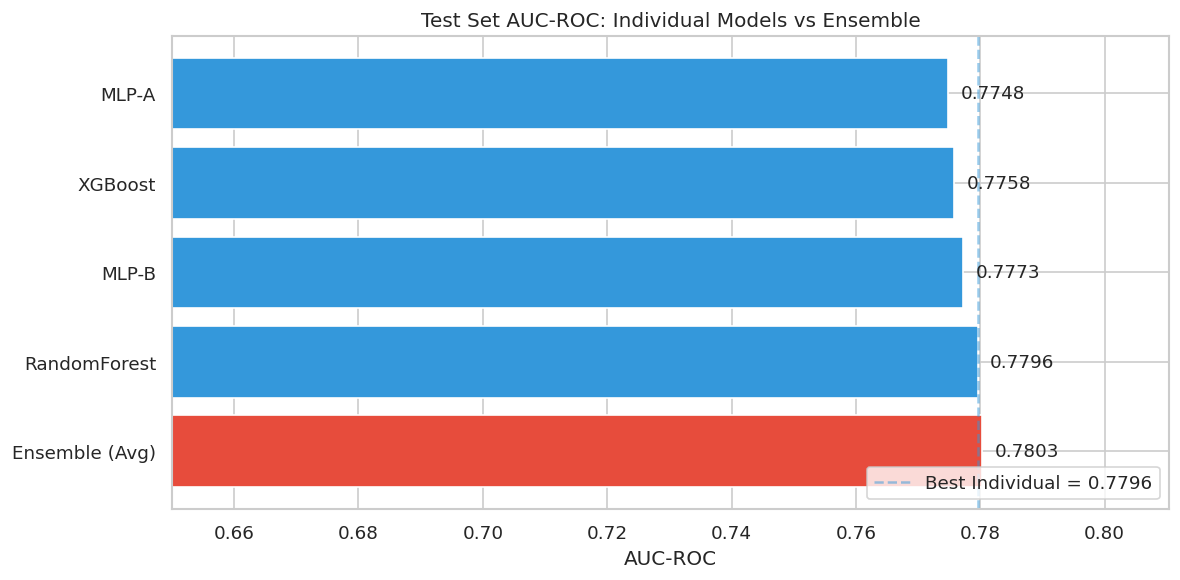

In [15]:
# --- Barplot comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db' if t == 'Individual' else '#e74c3c' for t in results_df['Type']]
bars = ax.barh(results_df['Model'], results_df['AUC-ROC'], color=colors)
for bar, val in zip(bars, results_df['AUC-ROC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11)
ax.set_xlabel('AUC-ROC')
ax.set_title('Test Set AUC-ROC: Individual Models vs Ensemble')
ax.axvline(x=best_individual_auc, color='#3498db', linestyle='--', alpha=0.5,
           label=f'Best Individual = {best_individual_auc:.4f}')
ax.legend(loc='lower right')
ax.set_xlim(0.65, max(results_df['AUC-ROC']) + 0.03)
plt.tight_layout()
plt.show()

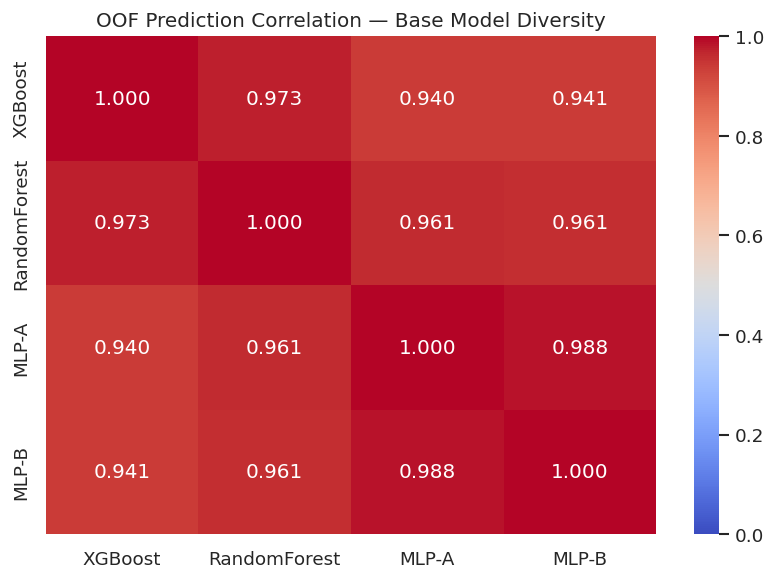

In [16]:
# --- OOF correlation heatmap — are base models diverse? ---
oof_df = pd.DataFrame(oof_predictions, columns=base_model_names)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(oof_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0, vmax=1, ax=ax)
ax.set_title('OOF Prediction Correlation — Base Model Diversity')
plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# Comprehensive metrics — beyond AUC-ROC
# =============================================================================

ens_hard = (ensemble_preds >= 0.5).astype(int)

metrics_rows = []
for name in base_model_names:
    preds_hard = (individual_preds[name] >= 0.5).astype(int)
    metrics_rows.append({
        'Model': name,
        'Precision': precision_score(y_test, preds_hard),
        'Recall':    recall_score(y_test, preds_hard),
        'F1':        f1_score(y_test, preds_hard),
        'Brier':     brier_score_loss(y_test, individual_preds[name]),
        'Avg Prec':  average_precision_score(y_test, individual_preds[name]),
    })

# Ensemble
ens_prec = precision_score(y_test, ens_hard)
ens_rec  = recall_score(y_test, ens_hard)
ens_f1   = f1_score(y_test, ens_hard)
metrics_rows.append({
    'Model': 'Ensemble (Avg)',
    'Precision': ens_prec, 'Recall': ens_rec, 'F1': ens_f1,
    'Brier': brier_score_loss(y_test, ensemble_preds),
    'Avg Prec': average_precision_score(y_test, ensemble_preds),
})

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print("Comprehensive Test Metrics:\n")
print(metrics_df.round(4).to_string())

# Log to MLflow
mlflow.log_params({
    'n_folds': N_FOLDS, 'n_base_models': len(base_model_names),
    'ensemble_method': 'simple_average',
})
mlflow.log_params({f'base_{name}': name for name in base_model_names})
mlflow.log_metrics({
    'test_auc': ens_auc, 'test_precision': ens_prec,
    'test_recall': ens_rec, 'test_f1': ens_f1,
    'test_brier': brier_score_loss(y_test, ensemble_preds),
})
for name in base_model_names:
    mlflow.log_metric(f'auc_{name}', roc_auc_score(y_test, individual_preds[name]))

Comprehensive Test Metrics:

                Precision  Recall      F1   Brier  Avg Prec
Model                                                      
XGBoost            0.4635  0.6245  0.5321  0.1790    0.5506
RandomForest       0.4777  0.6235  0.5409  0.1782    0.5559
MLP-A              0.4795  0.5984  0.5324  0.1842    0.5457
MLP-B              0.4817  0.5954  0.5326  0.1834    0.5430
Ensemble (Avg)     0.4886  0.6225  0.5475  0.1797    0.5586


In [19]:
# # --- ROC Curves: all models on one plot ---
# fig, ax = plt.subplots(figsize=(9, 7))
# colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
# for i, name in enumerate(base_model_names):
#     RocCurveDisplay.from_predictions(y_test, individual_preds[name],
#                                      ax=ax, name=f'{name}')
# RocCurveDisplay.from_predictions(y_test, ensemble_preds,
#                                  ax=ax, name='Ensemble (Avg)',
#                                  linewidth=2.5)
# ax.plot([0, 1], [0, 1], 'k--', alpha=0.2, label='Random')
# ax.set_title('ROC Curves — Individual Models vs Ensemble')
# ax.legend(loc='lower right', fontsize=9)
# plt.tight_layout()
# plt.show()


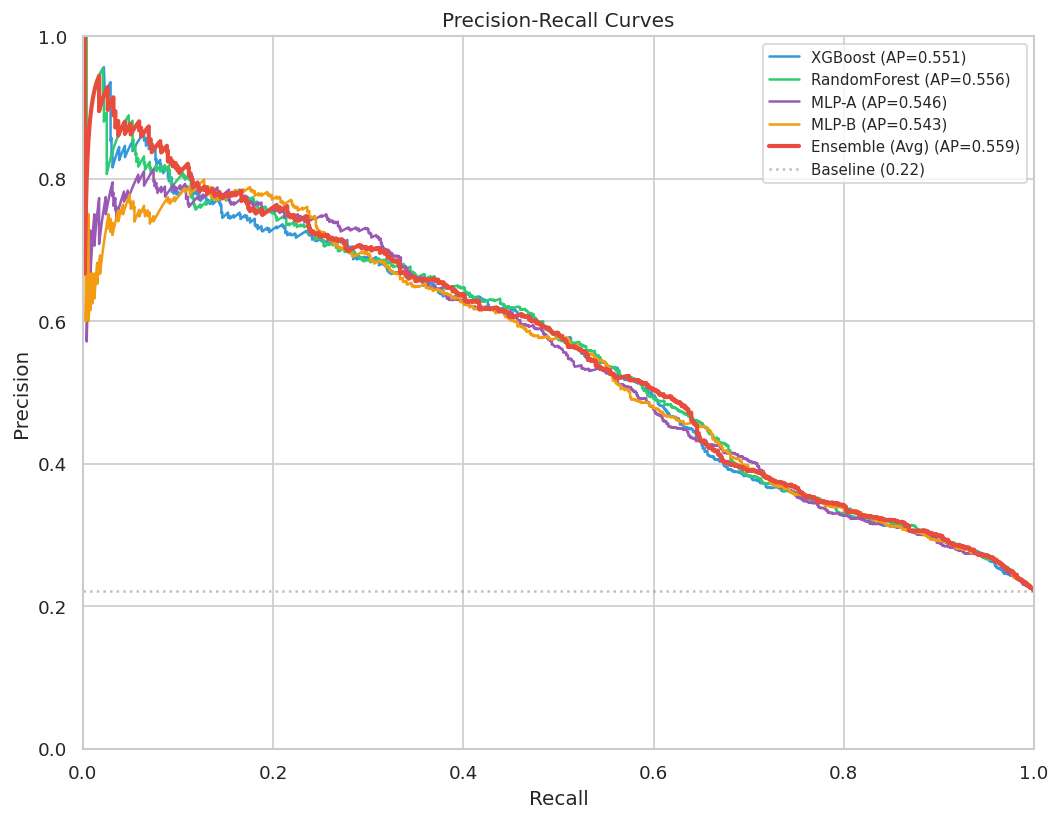

In [20]:
# --- Precision-Recall curves ---
fig, ax = plt.subplots(figsize=(9, 7))
for i, name in enumerate(base_model_names):
    prec, rec, _ = precision_recall_curve(y_test, individual_preds[name])
    ap = average_precision_score(y_test, individual_preds[name])
    ax.plot(rec, prec, color=colors[i], label=f'{name} (AP={ap:.3f})', linewidth=1.5)
prec, rec, _ = precision_recall_curve(y_test, ensemble_preds)
ap_ens = average_precision_score(y_test, ensemble_preds)
ax.plot(rec, prec, color=colors[4], linewidth=2.5,
        label=f'Ensemble (Avg) (AP={ap_ens:.3f})')
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle=':', alpha=0.5,
           label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

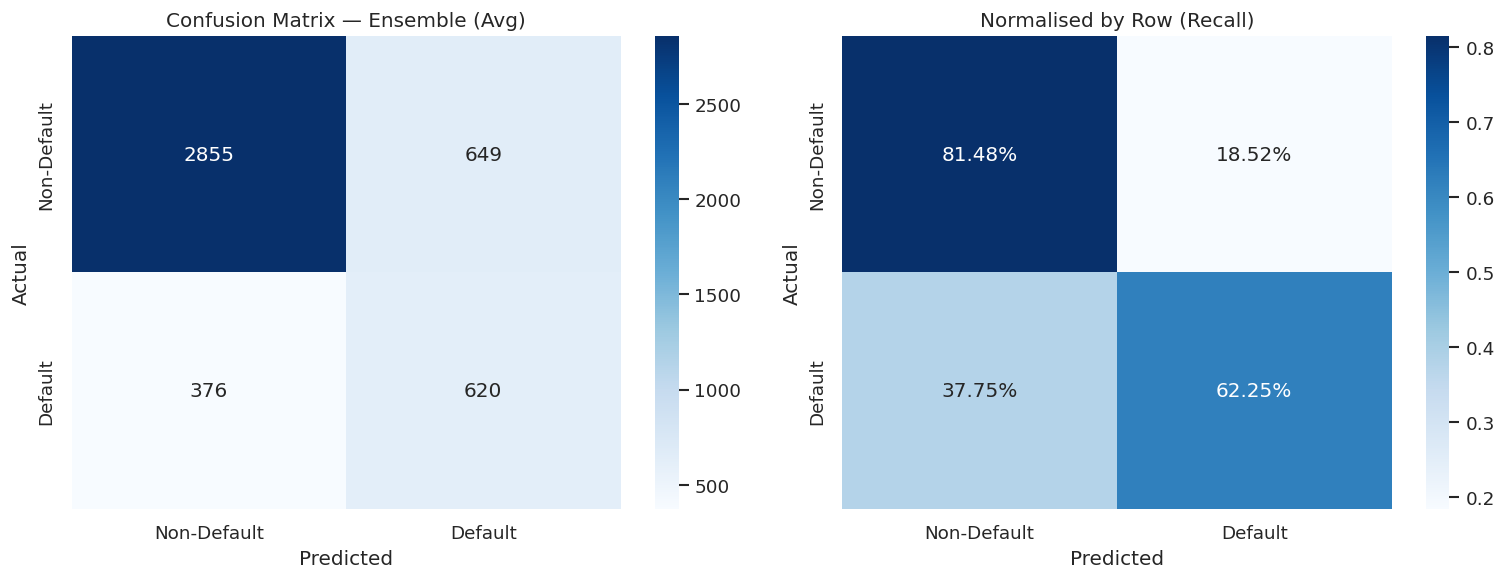

In [21]:
# --- Confusion matrix for the ensemble ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, ens_hard)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix — Ensemble (Avg)')
cm_norm = confusion_matrix(y_test, ens_hard, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.set_title('Normalised by Row (Recall)')
plt.tight_layout(); plt.show()

In [ ]:
# =============================================================================
# Standardised Evaluation — threshold=0.5 & max-F1 threshold
# =============================================================================
# Same metrics as the single-MLP notebook for apples-to-apples MLflow comparison.

from sklearn.metrics import precision_recall_curve

# --- Threshold = 0.5 ---
preds_05 = (ensemble_preds >= 0.5).astype(int)
auc   = roc_auc_score(y_test, ensemble_preds)
ap    = average_precision_score(y_test, ensemble_preds)
brier = brier_score_loss(y_test, ensemble_preds)
prec_05 = precision_score(y_test, preds_05)
rec_05  = recall_score(y_test, preds_05)
f1_05   = f1_score(y_test, preds_05)

# --- Max-F1 threshold ---
prec_curve, rec_curve, thresh = precision_recall_curve(y_test, ensemble_preds)
f1_curve = 2 * (prec_curve * rec_curve) / (prec_curve + rec_curve + 1e-10)
best_idx = np.argmax(f1_curve)
best_t   = thresh[best_idx]
preds_best = (ensemble_preds >= best_t).astype(int)
prec_best = precision_score(y_test, preds_best)
rec_best  = recall_score(y_test, preds_best)
f1_best   = f1_score(y_test, preds_best)

# --- Print ---
print(f"{'='*55}")
print(f"{'Metric':<20} {'thresh=0.5':>12} {'thresh='+f'{best_t:.2f}':>12}")
print(f"{'='*55}")
print(f"{'AUC-ROC':<20} {auc:>12.4f} {'—':>12}")
print(f"{'Avg Precision':<20} {ap:>12.4f} {'—':>12}")
print(f"{'Brier Score':<20} {brier:>12.4f} {'—':>12}")
print(f"{'Precision':<20} {prec_05:>12.4f} {prec_best:>12.4f}")
print(f"{'Recall':<20} {rec_05:>12.4f} {rec_best:>12.4f}")
print(f"{'F1':<20} {f1_05:>12.4f} {f1_best:>12.4f}")
print(f"{'='*55}")

# --- Log to MLflow ---
mlflow.log_metrics({
    'test_auc': auc, 'test_ap': ap, 'test_brier': brier,
    'test_precision_05': prec_05, 'test_recall_05': rec_05, 'test_f1_05': f1_05,
    'test_precision_best': prec_best, 'test_recall_best': rec_best, 'test_f1_best': f1_best,
    'test_threshold_best': best_t,
})


In [22]:
# --- Save models ---
import joblib

joblib.dump(xgb_final, f"{OUT_DIR}/xgb_final.pkl")
joblib.dump(rf_final,  f"{OUT_DIR}/rf_final.pkl")
torch.save(mlp_a_final.state_dict(), f"{OUT_DIR}/mlp_a_final.pt")
torch.save(mlp_b_final.state_dict(), f"{OUT_DIR}/mlp_b_final.pt")

config = {
    'base_model_names': base_model_names,
    'input_dim': input_dim,
    'n_folds': N_FOLDS,
}
with open(f"{OUT_DIR}/config.pkl", 'wb') as f:
    pickle.dump(config, f)

results_df.to_csv(f"{OUT_DIR}/results.csv", index=False)
metrics_df.to_csv(f"{OUT_DIR}/metrics.csv")

# Log to MLflow
for f in ['xgb_final.pkl', 'rf_final.pkl', 'mlp_a_final.pt', 'mlp_b_final.pt',
          'config.pkl', 'results.csv', 'metrics.csv']:
    mlflow.log_artifact(f"{OUT_DIR}/{f}")
mlflow.end_run()

print(f"Models saved to {OUT_DIR}/")
print(f"  xgb_final.pkl, rf_final.pkl, mlp_a_final.pt, mlp_b_final.pt")
print(f"  config.pkl, results.csv, metrics.csv")

Models saved to /home/momo/Documents/internship/week-03/credit-risk-pipeline/data-mining/building-nns/output/stacking-ensemble/
  xgb_final.pkl, rf_final.pkl, mlp_a_final.pt, mlp_b_final.pt
  config.pkl, results.csv, metrics.csv


In [23]:
# --- Ensure MLflow run is closed ---
if mlflow.active_run():
    mlflow.end_run()
    print('MLflow run ended.')
else:
    print('No active MLflow run.')


No active MLflow run.
